# A hands-on tour of **DIRFM** — driving DIRSIG from Python

This notebook is a build-it-up tutorial for **DIRFM** (`dirfm`), a Python library that
*writes DIRSIG input files and runs DIRSIG for you*. It assumes you know Python but have
never touched DIRSIG. We start from the absolute minimum render and add one concept per
section, running a real render at the end of every stage so you always see the effect of
what you just added.

## What is DIRSIG?

**DIRSIG** (Digital Imaging and Remote Sensing Image Generation, from RIT) is a
first-principles synthetic-image generator. You describe a *scene* (geometry + materials),
a *sensor* (optics + detector), the *platform motion*, the *atmosphere*, and a *time*, and
DIRSIG ray-traces a physically-based radiance image — the photons that would actually reach
that detector. It is used heavily for remote-sensing and EO/IR simulation.

## What problem does DIRFM solve?

DIRSIG is driven by a pile of hand-authored text files in several different formats:

| DIRSIG file | Format | Describes |
|---|---|---|
| `*.jsim` | JSON | top-level "job": which scenes, plugins, mediums |
| `*.scene` | XML (`classicscene`) | scene origin, materials file, geometry list |
| `*.odb` | custom text | procedural primitive objects (spheres, boxes…) |
| `*.glist` | XML | instanced mesh geometry (Wavefront `.obj`, GLB…) |
| `*.mat` | custom text | the material database + emissivity/BRDF references |
| `*.ppd` | XML (`platformmotion`) | platform position/orientation vs. time |
| `*.tasks` | XML (`tasklist`) | when the sensor collects (start/stop) |
| `*.atm` | XML (`atmosphericconditions`) | weather + radiative-transfer model |

Authoring and cross-referencing those by hand is tedious and error-prone. **DIRFM gives you
a Python object for each concept**, and `write_files()` / `run()` compiles the whole object
graph into that file set — no manual XML/JSON — then shells out to the DIRSIG binaries.

## The object model at a glance

```
DIRSIG(in_root, out_root)          # the "job" — becomes example.jsim
├── add_scene(SCENE, offset)       # one or more scenes, each -> a .scene (XML)
│     ├── materials  (Material…)   #   -> materials_*.mat  (<matfilename> in the .scene)
│     └── geometry   (ObjectDatabase | GLIST)   #  -> *.odb / *.glist (<geometrylist>)
└── add_plugin(Plugin)             # plugins are the platform & the atmosphere
      ├── PlatformSensorPlugin     #   -> "BasicPlatform": *.platform + *.ppd + *.tasks
      │     ├── set_motion(PlatformPosition)    #  -> example.ppd
      │     └── set_tasks(TASKS)                #  -> example.tasks
      └── BasicAtmospherePlugin    #   -> "BasicAtmosphere": example.atm
```

`DIRSIG.run()` calls `write_files()` (which emits everything above), then runs **`scene2hdf`**
(compiles each `.scene` into an HDF scene graph) and **`dirsig5`** (the renderer) as
subprocesses. The result is an ENVI image (`demo.img` + `demo.img.hdr`) we open and display.

> **The rest of the notebook is additive.** Each stage reuses and extends the objects from
> the previous one, so the *diff* between stages is the lesson. Every stage writes into its
> own `outputs/tutorial_<n>_input` / `outputs/tutorial_<n>_output` directories **inside this
> project** (`protoDIRSIG`); the `dirfm` checkout is only ever *read* (for its mesh assets).

## Stage 0 — Environment setup

DIRSIG's binaries are **not** Python; DIRFM finds them by shelling out to `scene2hdf` and
`dirsig5` on `PATH`. A Jupyter kernel does **not** inherit your interactive shell's `PATH`,
so we set it explicitly here.

The install location is read from the **`DIRSIG_HOME`** environment variable if it is set
(the conventional variable DIRSIG itself uses — the weather-file path below is written as
`$DIRSIG_HOME/...` and expanded by DIRSIG at run time). If it is unset, we fall back to this
machine's install, `~/DIRSIG/dirsig-2026.38.0.a020954-Linux-x86_64`. To point the notebook at
a different install, `export DIRSIG_HOME=...` before launching Jupyter rather than editing
the cell. We then assert both binaries resolve — if either `which` returns `None`, nothing
downstream can render.

In [1]:
import os
import shutil
from pathlib import Path

# DIRSIG_HOME from the environment if set; otherwise this machine's documented default.
DEFAULT_DIRSIG_HOME = Path.home() / "DIRSIG" / "dirsig-2026.38.0.a020954-Linux-x86_64"
DIRSIG_HOME = Path(os.environ.get("DIRSIG_HOME", DEFAULT_DIRSIG_HOME)).expanduser()

os.environ["DIRSIG_HOME"] = str(DIRSIG_HOME)          # re-export so DIRSIG sees it too
os.environ["PATH"] = f"{DIRSIG_HOME / 'bin'}{os.pathsep}" + os.environ.get("PATH", "")

print("DIRSIG_HOME =", DIRSIG_HOME)
print("scene2hdf ->", shutil.which("scene2hdf"))
print("dirsig5   ->", shutil.which("dirsig5"))
assert shutil.which("scene2hdf") and shutil.which("dirsig5"), \
    "DIRSIG binaries not on PATH — set DIRSIG_HOME to your DIRSIG install."


DIRSIG_HOME = /home/kevin-kearney/DIRSIG/dirsig-2026.38.0.a020954-Linux-x86_64
scene2hdf -> /home/kevin-kearney/DIRSIG/dirsig-2026.38.0.a020954-Linux-x86_64/bin/scene2hdf
dirsig5   -> /home/kevin-kearney/DIRSIG/dirsig-2026.38.0.a020954-Linux-x86_64/bin/dirsig5


### Imports and shared helpers

The DIRFM surface we will use, plus a couple of tiny utilities:

* `stage_dirs(n)` returns this stage's input/output directory pair.
* `render(...)` is the assembly boilerplate that is *identical* in every stage — build a
  `DIRSIG` job, attach the atmosphere plugin and the sensor plugin, add the scene at offset
  `[0,0,0]`, and `run()`. We show it once here so later stages can focus on *what changed*.
  (Stage 7 will expand it to show multi-scene offsets.)
* `show(...)` opens the ENVI radiance image with the `spectral` package and displays it.
  DIRSIG images are physical radiance with a huge dynamic range, so a naive
  `img / img.max()` is crushed to black by a few specular pixels — we apply a 2–98th
  percentile contrast stretch, the standard way to view this imagery.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from spectral import open_image

from dirfm import materials
from dirfm import object_database as odb
from dirfm import glist
from dirfm import platform_sensor as ps
from dirfm import atmosphere as atmos
from dirfm import platform_motion as pm
from dirfm import SCENE, DIRSIG, TASKS
from dirfm import frames

# Mesh assets are READ from the dirfm checkout (never written to). Everything this
# notebook generates is written under THIS project's outputs/ directory.
DIRFM_REPO = Path("/home/kevin-kearney/dev/dirsig-file-maker")   # edit if yours differs
GEOM = DIRFM_REPO / "demos" / "geometry"

PROJECT = Path.cwd()
if PROJECT.name == "notebooks":       # notebook lives in protoDIRSIG/notebooks/
    PROJECT = PROJECT.parent
OUTPUTS = PROJECT / "outputs"
OUTPUTS.mkdir(parents=True, exist_ok=True)

WEATHER = Path("$DIRSIG_HOME/lib/data/weather/mls.wth")  # $DIRSIG_HOME expanded by DIRSIG
print("PROJECT =", PROJECT)
print("OUTPUTS =", OUTPUTS)
print("GEOM    =", GEOM)


def stage_dirs(n):
    """Per-stage input (files DIRFM writes) and output (files DIRSIG writes) roots,
    both under this project's outputs/ directory."""
    return OUTPUTS / f"tutorial_{n}_input", OUTPUTS / f"tutorial_{n}_output"


def render(n, scene, sensor, atmosphere):
    """Assemble a one-scene DIRSIG job and run scene2hdf + dirsig5. Returns the .hdr path.

    `sensor` must already carry its motion and tasks (via .set_motion/.set_tasks).
    """
    in_dir, out_dir = stage_dirs(n)
    d = DIRSIG(in_dir, out_dir)          # becomes example.jsim
    d.add_plugin(atmosphere)             # -> "BasicAtmosphere" entry + example.atm
    d.add_plugin(sensor)                 # -> "BasicPlatform" entry + .platform/.ppd/.tasks
    d.add_scene(scene, [0, 0, 0])        # scene at scene-ENU offset (0,0,0)
    d.run()                              # write_files() -> scene2hdf -> dirsig5
    return out_dir / "demo.img.hdr"


def stretch(band, lo=2, hi=98):
    a, b = np.percentile(band, lo), np.percentile(band, hi)
    if b <= a:
        b = a + 1e-9
    return np.clip((band - a) / (b - a), 0, 1)


def show(hdr, bands, title):
    """Open an ENVI radiance cube and display the requested band(s), stretched."""
    cube = np.asarray(open_image(str(hdr)).load(), dtype=float)
    if len(bands) == 1:
        data, cmap = stretch(cube[:, :, bands[0]]), "gray"
    else:
        data, cmap = np.dstack([stretch(cube[:, :, b]) for b in bands]), None
    plt.figure(figsize=(6, 4.5))
    plt.imshow(data, cmap=cmap)
    plt.title(title)
    plt.axis("off")
    plt.show()
    print(f"{title}: cube shape = {cube.shape} (rows, cols, bands)")
    return cube

PROJECT = /home/kevin-kearney/dev/protoDIRSIG
OUTPUTS = /home/kevin-kearney/dev/protoDIRSIG/outputs
GEOM    = /home/kevin-kearney/dev/dirsig-file-maker/demos/geometry


---
# Stage 1 — The absolute minimum render

Our goal: get **one image out** with the fewest objects possible. We will build, in order,
the material, the geometry, the scene, the sensor, the motion, the tasks, and the atmosphere,
then assemble and render. Each sub-section explains the one object it creates.

### 1a. Materials

A DIRSIG **material** says how a surface interacts with light. In DIRFM a `Material` is
built up fluently:

* `GenericRadiationSolver(...)` — the Monte-Carlo radiometry solver settings (ray counts for
  the various bounce/sampling terms). `(10, 2, 2, 6, 12, 0)` is a solid general-purpose set.
* `WardBrdfSurfaceProperty([d0, d1], [s0, s1])` — a Ward BRDF: the first list is **diffuse
  reflectance** at the two ends of the spectral band, the second is the **specular**
  lobe. `[0.9, 0.9]` ≈ a flat 90%-reflective white; `[0.3, 0.3]` ≈ 30% gray.

Every `Material` you add to a scene becomes a block in the scene's `*.mat` file (referenced
by the `<matfilename>` element of the `.scene`). The `True` flag ties in thermal properties
— irrelevant for our daytime visible render, but required by the constructor.

In [3]:
white = (
    materials.Material("90% white", True)
    .set_rad_solver(materials.GenericRadiationSolver(10, 2, 2, 6, 12, 0))
    .add_surface_properties(materials.WardBrdfSurfaceProperty([0.9, 0.9], [0.05, 0.05]))
)
gray = (
    materials.Material("30% gray", True)
    .set_rad_solver(materials.GenericRadiationSolver(10, 2, 2, 6, 12, 0))
    .add_surface_properties(materials.WardBrdfSurfaceProperty([0.3, 0.3], [0.05, 0.05]))
)
materials_used = [white, gray]

### 1b. Geometry — an `ObjectDatabase` of procedural primitives

The simplest geometry source is an **`ObjectDatabase`** (compiled to a `*.odb` file): a list
of analytic primitives. Crucially, DIRFM lets you pass the **`Material` object itself**
straight into each primitive — DIRFM takes care of assigning an ID and wiring it to the
`.mat` file, so you never juggle material-ID strings by hand.

We start with a white `Sphere` (centre `[0,0,8]`, radius 8 m) resting on a gray
`GroundPlane` (an infinite plane anchored at the origin).

In [4]:
prims = [
    odb.Sphere([0, 0, 8.0], 8.0, white),
    odb.GroundPlane([0, 0, 0], gray),
]

def build_world(primitives):
    w = odb.ObjectDatabase()
    for p in primitives:
        w.add_object(p)
    return w

world = build_world(prims)

### 1c. The scene

A **`SCENE`** binds geometry + materials to a place and a set of enabled properties:

* `set_origin(GeodeticFrame(lat, lon, alt))` — the scene's `<sceneorigin>`; the ENU (East-
  North-Up) scene coordinates we use for object positions are anchored to this lat/lon.
* `add_geometry(name, world)` — adds a `<geometrylistinclude>` pointing at the `.odb`.
* `set_properties("vis")` — enables the *visible* radiometry pathway (as opposed to, e.g.,
  thermal `lwir`). This drives which physics DIRSIG bothers to compute.

In [5]:
def build_scene(name, world, mats):
    s = (
        SCENE(name)
        .set_origin(frames.GeodeticFrame(43, -77, 0))   # near Rochester, NY
        .set_properties("vis")
    )
    s.add_geometry("world", world)
    for m in mats:
        s.add_material(m)
    return s

scene = build_scene("demo", world, materials_used)

Material [Dummy] ID has already been set to [N/A], can't override.


### 1d. The sensor — a `PlatformSensorPlugin` tree

This is the largest object. A sensor in DIRSIG is a nested tree, and DIRFM mirrors that
tree exactly. Read it top-down:

* **`PlatformSensorPlugin`** — the platform plugin (`"BasicPlatform"` in the `.jsim`).
* **`StaticMount`** — a rigid mount; its rotation orients the instrument on the platform.
* **`GenericInstrument`** — the instrument body.
  * **`FocalLengthInstrumentProperty(500)`** — optics: a 500 mm focal length. Together with
    the detector pitch this sets the angular sampling (the ground footprint per pixel).
  * **`FocalPlane`** — the focal-plane assembly, which owns two things:
    * a **capture method** — `BasicCaptureMethod` with:
      * an **`ImageFile("demo")`** → output basename (`demo.img` / `demo.img.hdr`);
      * a **`SpectralResponse`** with a **band** (`0.4–0.8 µm`) and one or more **channels**.
        A **`FunctionalChannel(name, center, width)`** is one output band — here a single
        panchromatic channel centred at `0.6 µm`, `0.4 µm` wide.
    * a **`DetectorArray`** — the pixel grid:
      * an **`IndependentDetectorClock(rate, offset)`** — the per-detector readout clock;
      * **`set_elements(nx, ny, xpitch, ypitch, xspace, yspace, xoff, yoff, flipx, flipy)`**
        — here a `200×150` array of `8 µm` detectors. `nx × ny` is exactly the pixel size of
        the image you'll get back.
  * a **`TruthCollection`** — asks DIRSIG to also emit per-pixel "truth" (here the
    intersection geometry). Not displayed, but handy downstream.

In [6]:
def build_pan_camera():
    return ps.PlatformSensorPlugin().add_attachment(
        ps.Attachment(
            ps.StaticMount("Mount").set_rotation("xyz", "degrees", 0, 0, 0)
        ).add_attachment(
            ps.Attachment(
                ps.GenericInstrument("Instrument")
                .add_property(ps.FocalLengthInstrumentProperty(500))
                .add_focal_plane(
                    ps.FocalPlane("FPA")
                    .set_capture_method(
                        ps.BasicCaptureMethod("Simple")
                        .set_image_file(ps.ImageFile("demo"))
                        .set_spectral_response(
                            ps.SpectralResponse()
                            .set_band("microns", 0.4, 0.8)
                            .add_channel(ps.FunctionalChannel("Pan", 0.6, 0.4))
                        )
                    )
                    .set_detector_array(
                        ps.DetectorArray("microns")
                        .set_clock(ps.IndependentDetectorClock(1, 0))
                        .set_elements(200, 150, 8, 8, 8, 8, 0, 0, False, True)
                    )
                    .set_truth_collection(
                        ps.TruthCollection("truth").add_collection("Intersection")
                    )
                )
            )
        )
    )

sensor = build_pan_camera()

### 1e. Platform motion

**`PlatformPosition`** is the platform trajectory (compiled to `example.ppd`). Each
`add_entry(time, [x,y,z], [rx,ry,rz])` is a keyframe: a relative time (seconds), an ENU
position in metres, and an orientation (radians here). For a single still frame we give
**one** entry: the camera sits ~17 km away, up at 12 km, looking down at the scene.

In [7]:
def static_view():
    return pm.PlatformPosition().add_entry(
        0, [-4000, -12000, 12000], [0.81172612, 0, 5.9614475]
    )

motion = static_view()

### 1f. Tasks — when does the sensor collect?

**`TASKS`** (compiled to `example.tasks`) holds an absolute **reference datetime** (sun
position, so lighting, depends on it) plus one or more **start/stop** windows given as
*relative* seconds from that reference. `add_start_stop(0, 0)` is a single instantaneous
capture at t = 0.

In [8]:
from datetime import datetime, timezone, timedelta

def snapshot(t=0):
    ref = datetime(2009, 9, 1, 10, 10, 0, 0, timezone(-timedelta(hours=5)))  # 10:10 local, EST
    return TASKS(ref).add_start_stop(t, t)

tasks = snapshot(0)

### 1g. Atmosphere

The **`BasicAtmospherePlugin`** (`"BasicAtmosphere"` → `example.atm`) needs a weather source
and a radiative-transfer model. We use the smallest RT model, **`SimpleRadiativeTransfer`**,
which just models the sky as a single apparent temperature (260 K) — cheap, and enough to
light the scene. The weather file ships with DIRSIG.

In [9]:
def simple_atmosphere():
    return (
        atmos.BasicAtmospherePlugin()
        .set_radiative_transfer(atmos.SimpleRadiativeTransfer(260))
        .set_weather(WEATHER)
    )

atmosphere = simple_atmosphere()

### 1h. Assemble and render

Now hand motion + tasks to the sensor, and pass everything to `render()`. This is where
`write_files()` emits the `.jsim/.scene/.odb/.mat/.ppd/.tasks/.atm`, then `scene2hdf` and
`dirsig5` run. First render will take a few seconds.

[warn] Found infinite plane geometry, emulating with a limited, facetized representation.



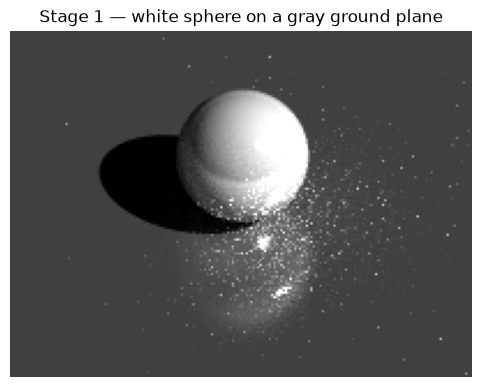

Stage 1 — white sphere on a gray ground plane: cube shape = (150, 200, 1) (rows, cols, bands)


In [10]:
hdr = render(1, scene, sensor.set_motion(motion).set_tasks(tasks), atmosphere)
show(hdr, [0], "Stage 1 — white sphere on a gray ground plane");

---
# Stage 2 — More geometry and materials

Now we *extend* the scene. Two new materials and three new primitives are added to the very
same `prims` list from Stage 1 — note we pass `Material` **objects** directly into each
primitive; there is never a material-ID string to keep in sync (DIRFM assigns and wires the
IDs when it writes the `.odb` and `.mat`).

Material [Dummy] ID has already been set to [N/A], can't override.


Material [90% white] ID has already been set to [auto_2], can't override.


Material [30% gray] ID has already been set to [auto_3], can't override.


[warn] Found infinite plane geometry, emulating with a limited, facetized representation.



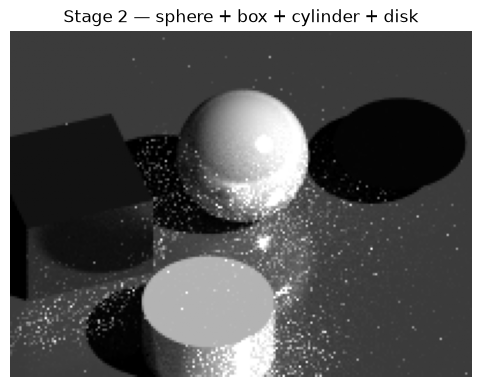

Stage 2 — sphere + box + cylinder + disk: cube shape = (150, 200, 1) (rows, cols, bands)


In [11]:
red = (
    materials.Material("reflective red-ish", True)
    .set_rad_solver(materials.GenericRadiationSolver(10, 2, 2, 6, 12, 0))
    .add_surface_properties(materials.WardBrdfSurfaceProperty([0.1, 0.7], [0.05, 0.05]))
)
dark = (
    materials.Material("3% dark", False)
    .set_rad_solver(materials.GenericRadiationSolver(1, 1, 2, 6, 12, 0))
    .add_surface_properties(materials.WardBrdfSurfaceProperty([0.03, 0.03], [0.05, 0.05]))
)
materials_used += [red, dark]

# Extend the SAME primitive list from Stage 1 (additive):
prims += [
    odb.Box([-30, -8, 0], [-14, 8, 12], red),                 # a red-ish block
    odb.Cylinder([-12, -23, 0], [-12, -23, 8], 8.0, True, True, white),  # capped cylinder
    odb.Disk([20.0, 0, 4.0], 8.0, dark),                      # a dark disk
]

world = build_world(prims)
scene = build_scene("demo", world, materials_used)
hdr = render(2, scene, build_pan_camera().set_motion(static_view()).set_tasks(snapshot(0)),
             simple_atmosphere())
show(hdr, [0], "Stage 2 — sphere + box + cylinder + disk");

---
# Stage 3 — Sensor realism: a wider band and multiple channels

Stage 1's camera had **one** channel → a single-band (grayscale) image. Here we make an RGB
camera to expose the FocalPlane → CaptureMethod → DetectorArray relationship:

* The **`SpectralResponse`** band is the *union* wavelength range the focal plane models
  (`0.4–0.7 µm` here). It must **cover every channel** — DIRFM warns at write time if a
  channel falls outside the band or the materials don't cover it.
* Each **`FunctionalChannel(name, center, width)`** added to the `SpectralResponse` becomes
  **one output band**, in the order added. Three channels (R, G, B) → a 3-band cube, which is
  why the returned `cube.shape` third axis is now `3`.
* We also grow the **`DetectorArray`** to `320×240`, so the image comes back at 320×240
  pixels. Detector count is independent of channel count: the array defines the *spatial*
  grid, the spectral response defines the *bands*.

We factor the camera into `make_rgb_camera()` so later stages can reuse it.

Material [Dummy] ID has already been set to [N/A], can't override.


Material [90% white] ID has already been set to [auto_2], can't override.


Material [30% gray] ID has already been set to [auto_3], can't override.


Material [reflective red-ish] ID has already been set to [auto_4], can't override.


Material [3% dark] ID has already been set to [auto_5], can't override.


[warn] Found infinite plane geometry, emulating with a limited, facetized representation.



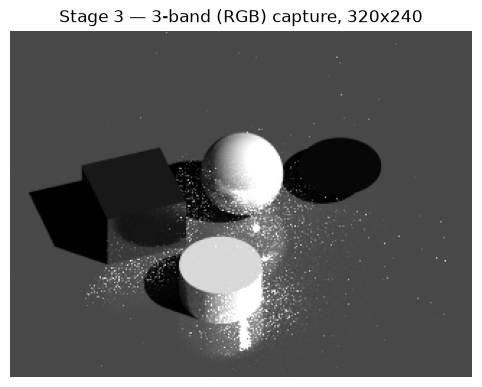

Stage 3 — 3-band (RGB) capture, 320x240: cube shape = (240, 320, 3) (rows, cols, bands)
channels -> 3


In [12]:
def make_rgb_camera(focal=500, nx=320, ny=240, pitch=8):
    sr = (
        ps.SpectralResponse()
        .set_band("microns", 0.4, 0.7)
        .add_channel(ps.FunctionalChannel("Red", 0.65, 0.10))
        .add_channel(ps.FunctionalChannel("Green", 0.55, 0.10))
        .add_channel(ps.FunctionalChannel("Blue", 0.45, 0.10))
    )
    return ps.PlatformSensorPlugin().add_attachment(
        ps.Attachment(
            ps.StaticMount("Mount").set_rotation("xyz", "degrees", 0, 0, 0)
        ).add_attachment(
            ps.Attachment(
                ps.GenericInstrument("Instrument")
                .add_property(ps.FocalLengthInstrumentProperty(focal))
                .add_focal_plane(
                    ps.FocalPlane("FPA")
                    .set_capture_method(
                        ps.BasicCaptureMethod("Simple")
                        .set_image_file(ps.ImageFile("demo"))
                        .set_spectral_response(sr)
                    )
                    .set_detector_array(
                        ps.DetectorArray("microns")
                        .set_clock(ps.IndependentDetectorClock(1, 0))
                        .set_elements(nx, ny, pitch, pitch, pitch, pitch, 0, 0, False, True)
                    )
                    .set_truth_collection(
                        ps.TruthCollection("truth").add_collection("Intersection")
                    )
                )
            )
        )
    )

scene = build_scene("demo", build_world(prims), materials_used)
hdr = render(3, scene, make_rgb_camera().set_motion(static_view()).set_tasks(snapshot(0)),
             simple_atmosphere())
cube = show(hdr, [0, 1, 2], "Stage 3 — 3-band (RGB) capture, 320x240")
print("channels ->", cube.shape[2])

---
# Stage 4 — Platform motion and timing

Stage 1's trajectory had a single keyframe. Now we give **two** keyframes, so the platform
*moves* between them, and DIRSIG interpolates position/orientation over relative time.

The trajectory descends along the view ray — from `[-4000,-12000,12000]` at t=0 to
`[-2000,-6000,6000]` at t=10 s (halfway to the origin) — keeping the same look angles so the
scene stays framed but appears *closer*. We then task the sensor at **t = 5 s** (the
midpoint) instead of t = 0, so the captured vantage is the interpolated pose.

**Relative vs. absolute time:** the `TASKS` *reference* datetime is **absolute** (it fixes
the sun angle / lighting for the whole simulation). Both the `PlatformPosition` keyframe
times and the `TASKS` start/stop are **relative** seconds measured from that reference. So
"t = 5" means "5 s after 2009-09-01 10:10 EST", and the platform is wherever the trajectory
interpolates to at that instant.

Material [Dummy] ID has already been set to [N/A], can't override.


Material [90% white] ID has already been set to [auto_2], can't override.


Material [30% gray] ID has already been set to [auto_3], can't override.


Material [reflective red-ish] ID has already been set to [auto_4], can't override.


Material [3% dark] ID has already been set to [auto_5], can't override.


[warn] Found infinite plane geometry, emulating with a limited, facetized representation.



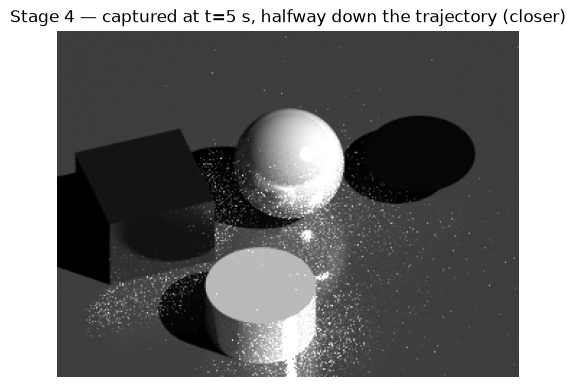

Stage 4 — captured at t=5 s, halfway down the trajectory (closer): cube shape = (240, 320, 3) (rows, cols, bands)


In [13]:
def descending_view():
    return (
        pm.PlatformPosition()
        .add_entry(0,  [-4000, -12000, 12000], [0.81172612, 0, 5.9614475])
        .add_entry(10, [-2000,  -6000,  6000], [0.81172612, 0, 5.9614475])
    )

scene = build_scene("demo", build_world(prims), materials_used)
hdr = render(4, scene,
             make_rgb_camera().set_motion(descending_view()).set_tasks(snapshot(5)),
             simple_atmosphere())
show(hdr, [0, 1, 2], "Stage 4 — captured at t=5 s, halfway down the trajectory (closer)");

---
# Stage 5 — Atmosphere fidelity

Stage 1's `SimpleRadiativeTransfer(260)` modeled the sky as a single apparent temperature —
it lights the scene but carries no real spectral/angular sky structure. Here we swap in
**`UniformRadiativeTransfer(hemisphere_irradiance, sky_fraction)`**, which instead models a
uniform downwelling **hemispheric irradiance** and the **fraction of the sky** each surface
sees.

Physically this changes the *illumination bookkeeping*: rather than "the sky is a 260 K
blackbody," DIRSIG now distributes a specified diffuse sky irradiance over the hemisphere and
weights it by how much open sky each surface point can see (so a point tucked beside the box
receives less sky than the open ground). The geometry is identical to Stage 3 — only the
`.atm`'s `<radiativetransfer>` block changes — so any difference in the render is purely the
atmosphere model.

Material [Dummy] ID has already been set to [N/A], can't override.


Material [90% white] ID has already been set to [auto_2], can't override.


Material [30% gray] ID has already been set to [auto_3], can't override.


Material [reflective red-ish] ID has already been set to [auto_4], can't override.


Material [3% dark] ID has already been set to [auto_5], can't override.


[warn] Found infinite plane geometry, emulating with a limited, facetized representation.



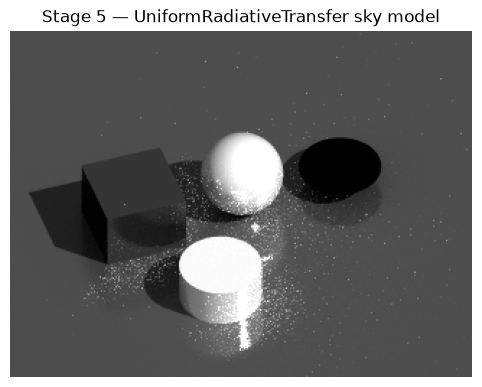

Stage 5 — UniformRadiativeTransfer sky model: cube shape = (240, 320, 3) (rows, cols, bands)


In [14]:
def uniform_atmosphere():
    return (
        atmos.BasicAtmospherePlugin()
        .set_radiative_transfer(atmos.UniformRadiativeTransfer(1, 0.3))
        .set_weather(WEATHER)
    )

scene = build_scene("demo", build_world(prims), materials_used)
hdr = render(5, scene, make_rgb_camera().set_motion(static_view()).set_tasks(snapshot(0)),
             uniform_atmosphere())
show(hdr, [0, 1, 2], "Stage 5 — UniformRadiativeTransfer sky model");

---
# Stage 6 — Mesh geometry via GLIST

So far all geometry has been *procedural primitives* in an `ObjectDatabase`. Real assets are
usually **meshes**. DIRSIG's mechanism for that is a **GLIST** (`*.glist`): a list of
**instances** of **base geometries** (Wavefront `.obj`, GLB, nested GLISTs…).

**GLIST vs. ObjectDatabase:**

| | `ObjectDatabase` (`.odb`) | `GLIST` (`.glist`) |
|---|---|---|
| what | analytic primitives | *instanced* mesh geometry |
| reuse | each object stated once | one mesh, many `StaticInstance`s (cheap) |
| placement | baked into the primitive's coords | per-instance translate / rotate / scale |

The building blocks:

* **`glist.Wavefront(path)`** loads a `.obj` and auto-discovers its `usemtl` groups. You must
  map **every** one to a DIRFM `Material` via `.assign_material(material, "<obj_mtl_name>")`
  or DIRSIG errors with "material … not defined". Our `737.obj` uses a single group, `"2"`.
* **`glist.StaticInstance(name, translation, rotation, scale)`** places one copy. `rotation`
  is in degrees; `scale` is per-axis.
* **`glist.Object(base_geometry, instance)`** pairs a geometry with an instance; `GLIST.add_object`
  collects them.

A `SCENE` accepts a `GLIST` through the *same* `add_geometry(...)` call as an `ObjectDatabase`
— it just writes a `.glist` instead of a `.odb`. We put the jet on a gray ground plane.

Material [Dummy] ID has already been set to [N/A], can't override.


Material [90% white] ID has already been set to [auto_2], can't override.


Material [30% gray] ID has already been set to [auto_3], can't override.


[warn] Found infinite plane geometry, emulating with a limited, facetized representation.



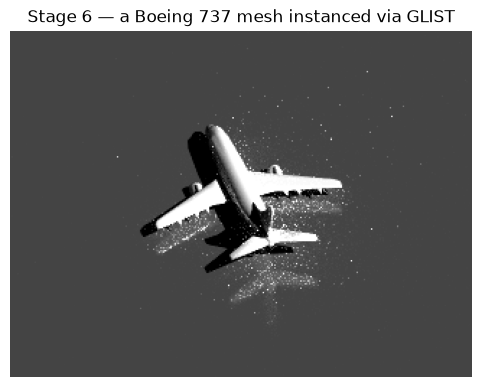

Stage 6 — a Boeing 737 mesh instanced via GLIST: cube shape = (240, 320, 3) (rows, cols, bands)


In [15]:
def build_mesh_world(mats):
    w = glist.GLIST()
    w.add_object(glist.Object(
        glist.GroundPlane([0, 0, 0], mats["ground"]),
        glist.StaticInstance("ground"),
    ))
    w.add_object(glist.Object(
        glist.Wavefront(GEOM / "737.obj").assign_material(mats["skin"], "2"),
        glist.StaticInstance("jet", translation=[0, 0, 6], rotation=[0, 0, 0], scale=[1.5, 1.5, 1.5]),
    ))
    return w

mesh_mats = {"skin": white, "ground": gray}
scene = (
    SCENE("mesh")
    .set_origin(frames.GeodeticFrame(43, -77, 0))
    .set_properties("vis")
)
scene.add_geometry("world", build_mesh_world(mesh_mats))
for m in mesh_mats.values():
    scene.add_material(m)

hdr = render(6, scene, make_rgb_camera().set_motion(static_view()).set_tasks(snapshot(0)),
             simple_atmosphere())
show(hdr, [0, 1, 2], "Stage 6 — a Boeing 737 mesh instanced via GLIST");

---
# Stage 7 — Wrap-up: composing multiple scenes

A `DIRSIG` job can hold **more than one scene**, each placed at its own ENU **offset** via
`add_scene(scene, [dx, dy, dz])`. This is how you compose independently-authored scenes into
one render without editing either one. Here we combine everything we've built:

* **Scene A** — a procedural `ObjectDatabase` (sphere + box), at offset `[0, 0, 0]`.
* **Scene B** — the GLIST mesh jet, shifted to `[35, -15, 0]` and rotated 45°.

> **One gotcha we handle here:** a DIRFM `SCENE`/`Material` caches the file it wrote on first
> use. Because both scenes are compiled inside a *single* job (sharing one materials
> directory), Scene B gets a **fresh** set of `Material` objects rather than reusing Scene A's
> — otherwise the second scene's materials would resolve to the first scene's cached files.
> (Across *separate* stages above this was a non-issue, since each stage was its own job.)

This is the only stage that doesn't use the `render()` helper, precisely because it adds two
scenes at different offsets.

Material [Dummy] ID has already been set to [N/A], can't override.


Material [90% white] ID has already been set to [auto_2], can't override.


Material [30% gray] ID has already been set to [auto_3], can't override.


Material [reflective red-ish] ID has already been set to [auto_4], can't override.


Material [Dummy] ID has already been set to [N/A], can't override.


[warn] Found infinite plane geometry, emulating with a limited, facetized representation.



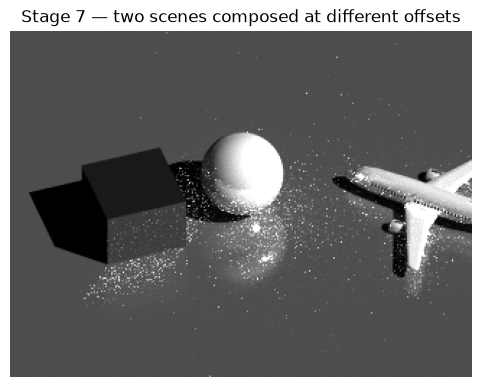

Stage 7 — two scenes composed at different offsets: cube shape = (240, 320, 3) (rows, cols, bands)


In [16]:
in_dir, out_dir = stage_dirs(7)

# Scene A: procedural primitives
worldA = odb.ObjectDatabase()
worldA.add_object(odb.Sphere([0, 0, 8.0], 8.0, white))
worldA.add_object(odb.GroundPlane([0, 0, 0], gray))
worldA.add_object(odb.Box([-30, -8, 0], [-14, 8, 12], red))
sceneA = build_scene("primitives", worldA, [white, gray, red])

# Scene B: the mesh jet, with its OWN fresh materials (see note above)
whiteB = (
    materials.Material("skinB", True)
    .set_rad_solver(materials.GenericRadiationSolver(10, 2, 2, 6, 12, 0))
    .add_surface_properties(materials.WardBrdfSurfaceProperty([0.9, 0.9], [0.05, 0.05]))
)
grayB = (
    materials.Material("groundB", True)
    .set_rad_solver(materials.GenericRadiationSolver(10, 2, 2, 6, 12, 0))
    .add_surface_properties(materials.WardBrdfSurfaceProperty([0.3, 0.3], [0.05, 0.05]))
)
worldB = glist.GLIST()
worldB.add_object(glist.Object(
    glist.Wavefront(GEOM / "737.obj").assign_material(whiteB, "2"),
    glist.StaticInstance("jet", translation=[0, 0, 6], rotation=[0, 0, 45], scale=[1.5, 1.5, 1.5]),
))
sceneB = SCENE("mesh").set_origin(frames.GeodeticFrame(43, -77, 0)).set_properties("vis")
sceneB.add_geometry("world", worldB)
for m in (whiteB, grayB):
    sceneB.add_material(m)

d = DIRSIG(in_dir, out_dir)
d.add_plugin(simple_atmosphere())
d.add_plugin(make_rgb_camera().set_motion(static_view()).set_tasks(snapshot(0)))
d.add_scene(sceneA, [0, 0, 0])       # primitives at the origin
d.add_scene(sceneB, [35, -15, 0])    # jet composited in, offset in scene-ENU metres
d.run()
show(out_dir / "demo.img.hdr", [0, 1, 2], "Stage 7 — two scenes composed at different offsets");

---
## The full object graph we built

```
DIRSIG(outputs/tutorial_7_input, outputs/tutorial_7_output)   # -> example.jsim (the job)
│
├── add_plugin( BasicAtmospherePlugin )                # -> "BasicAtmosphere" + example.atm
│                └── SimpleRadiativeTransfer(260)       #    <radiativetransfer> block
│                └── weather = mls.wth                  #    <uniformweather><classicdata>
│
├── add_plugin( PlatformSensorPlugin )                 # -> "BasicPlatform" + .platform/.ppd/.tasks
│     ├── StaticMount ── GenericInstrument
│     │        ├── FocalLengthInstrumentProperty(500)  #    optics
│     │        └── FocalPlane
│     │             ├── BasicCaptureMethod
│     │             │     ├── ImageFile("demo")         #    -> demo.img(.hdr)
│     │             │     └── SpectralResponse          #    band 0.4-0.7 um
│     │             │           ├── FunctionalChannel R #      -> image band 0
│     │             │           ├── FunctionalChannel G #      -> image band 1
│     │             │           └── FunctionalChannel B #      -> image band 2
│     │             └── DetectorArray 320x240           #    -> image is 320x240 px
│     │                   └── IndependentDetectorClock
│     ├── set_motion( PlatformPosition )                # -> example.ppd (keyframes vs. time)
│     └── set_tasks(  TASKS )                           # -> example.tasks (ref datetime + start/stop)
│
├── add_scene( SCENE "primitives", offset=[0,0,0] )    # -> a .scene (XML)
│     ├── GeodeticFrame(43,-77,0)                       #    <sceneorigin>
│     ├── materials: white, gray, red                  #    -> materials_*.mat  (<matfilename>)
│     │        each = GenericRadiationSolver + WardBrdfSurfaceProperty
│     └── ObjectDatabase                                #    -> *.odb  (<geometrylist>)
│              Sphere, GroundPlane, Box
│
└── add_scene( SCENE "mesh", offset=[35,-15,0] )       # -> a second .scene
      ├── materials: whiteB, grayB
      └── GLIST                                          #    -> *.glist
               Object( Wavefront("737.obj"), StaticInstance )
```

`DIRSIG.run()` compiled all of the above into that file set, ran **`scene2hdf`** once per
scene to build the HDF scene graph, then **`dirsig5`** to ray-trace the radiance image we
opened with `spectral` and displayed.

### Where to go next
* **Materials:** emissivity/BRDF from measured data, thermal solvers (see `dirfm.materials`,
  `dirfm.emissivity`, and the `test_Thermal*.py` / `test_Brdf1.py` demos).
* **Motion:** `dirfm.flexible_motion` (`FlexMotion` with location/orientation *engines*) for
  fly-bys and look-at behaviour — see `demos/test_FlexMotion1.py`.
* **Atmosphere:** `ClassicRadiativeTransfer` (MODTRAN tape5) or `FourCurveAtmospherePlugin`
  for high-fidelity spectral atmospheres.
* **Bundles:** `dirfm.bundle` + `glist.GlistBaseGeometry` to drop in pre-packaged assets with
  their own materials (see `demos/test_BundledObject1.py`).

---
# Stage 8 — Determinism and render-quality knobs

Everything so far used DIRSIG's default sampling and an unspecified random seed. For a batch
driver we need to know two things empirically, not by assumption:

1. **Is a run reproducible**, and if so, to what standard — *bitwise-identical* files, or only
   *statistically similar* images (same expected radiance, different Monte-Carlo noise)?
2. **What the quality knobs cost** — how wall-clock time and image quality trade off.

DIRFM exposes both through `DIRSIG` (see `set_seed()` and `run()` in `dirfm/dirsig.py`):

* **`DIRSIG.set_seed(seed)`** stores an `int`; `run()` then appends `--random_seed <seed>` to
  **both** the `scene2hdf` and the `dirsig5` command lines.
* **`DIRSIG.run(**options)`** forwards every keyword argument to `dirsig5` as a
  `--key=value` flag (or a bare `--key` if the value is `None`). DIRFM does not validate
  them, so any `dirsig5 --help` option is reachable: `run(convergence="3,3,0", max_nodes="1")`
  becomes `dirsig5 example.jsim --output_folder=... --convergence=3,3,0 --max_nodes=1`.

To isolate seed/convergence behaviour, this stage deliberately goes back to **Stage 1's**
configuration — the white sphere on the gray plane, the single-channel pan camera, the fixed
viewpoint, the single snapshot and the `SimpleRadiativeTransfer` atmosphere — rebuilt from
the very same Stage 1 builder functions (`build_world`, `build_scene`, `build_pan_camera`,
`static_view`, `snapshot`, `simple_atmosphere`). `prims[:2]` is exactly Stage 1's primitive
list (sphere + ground plane) before Stage 2 extended it.

### 8a. Determinism — run the identical job twice with the same seed

`stage1_job()` below assembles Stage 1's job into its own `outputs/tutorial_8_<tag>_*`
directory pair, optionally seeds it, runs it with any extra `dirsig5` options, and returns the
radiance cube, the wall-clock time of `run()` (which includes `write_files()` and `scene2hdf`
as well as `dirsig5`), and a SHA-256 of the raw `demo.img` bytes.

We compare at two strengths: `numpy.array_equal` on the loaded arrays (every float equal) and
the file hash (every byte equal). A few control runs make the result interpretable:

| run | seed | why |
|---|---|---|
| `seedA`, `seedB` | 42 | the actual reproducibility test — identical config, two output dirs |
| `seed43` | 43 | control: if this *also* matched, the seed wouldn't be doing anything |
| `seedA_1thread` | 42, `threads=1` | does the work split across threads change the result? (also shows `run()` kwarg forwarding) |
| `noseed` / `seed0` | none / 0 | what does an *unseeded* run correspond to? |

Material [Dummy] ID has already been set to [N/A], can't override.


Material [90% white] ID has already been set to [auto_2], can't override.


Material [30% gray] ID has already been set to [auto_3], can't override.


[warn] Found infinite plane geometry, emulating with a limited, facetized representation.



Material [Dummy] ID has already been set to [N/A], can't override.


...

Material [Dummy] ID has already been set to [N/A], can't override.


Material [90% white] ID has already been set to [auto_2], can't override.


Material [30% gray] ID has already been set to [auto_3], can't override.


[warn] Found infinite plane geometry, emulating with a limited, facetized representation.



        seedA: sha256=12d6b8d366c0579f…  run()=  6.0s
        seedB: sha256=12d6b8d366c0579f…  run()=  6.8s
       seed43: sha256=e7fc06e511a1917b…  run()=  6.0s
seedA_1thread: sha256=12d6b8d366c0579f…  run()= 17.3s
       noseed: sha256=852349bd269a4a09…  run()=  5.2s
        seed0: sha256=852349bd269a4a09…  run()=  5.3s

        seedA vs seedB         array_equal=True   sha256 equal=True   max|diff|=0.000e+00  mean|diff|/mean=0.00%
        seedA vs seed43        array_equal=False  sha256 equal=False  max|diff|=8.059e-02  mean|diff|/mean=5.79%
        seedA vs seedA_1thread array_equal=True   sha256 equal=True   max|diff|=0.000e+00  mean|diff|/mean=0.00%
       noseed vs seed0         array_equal=True   sha256 equal=True   max|diff|=0.000e+00  mean|diff|/mean=0.00%
seed 42 vs 43: 52% of pixels differ; 12% by more than 10% of their value


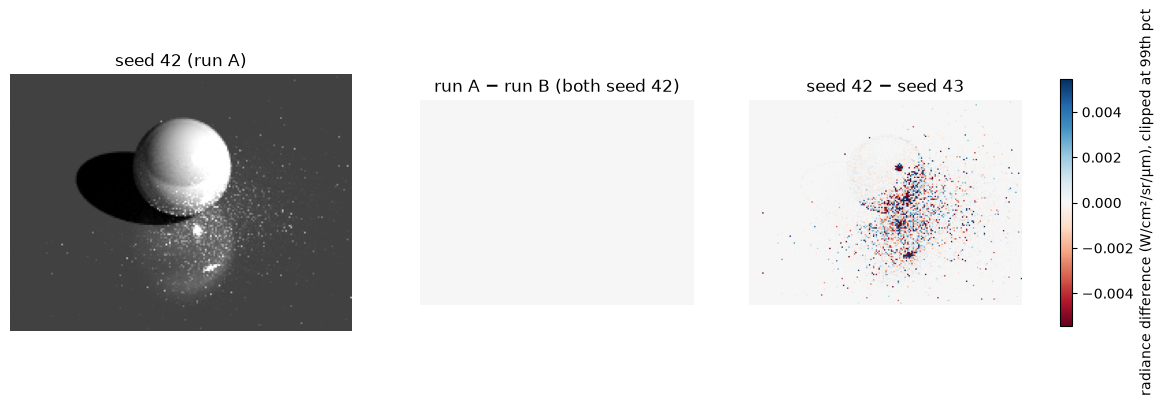

In [17]:
import time
import hashlib

def stage1_job(tag, seed=None, **run_options):
    """Stage 1's exact configuration, run into outputs/tutorial_8_<tag>_{input,output}."""
    in_dir, out_dir = stage_dirs(f"8_{tag}")
    d = DIRSIG(in_dir, out_dir)
    d.add_plugin(simple_atmosphere())
    d.add_plugin(build_pan_camera().set_motion(static_view()).set_tasks(snapshot(0)))
    d.add_scene(build_scene("demo", build_world(prims[:2]), [white, gray]), [0, 0, 0])
    if seed is not None:
        d.set_seed(seed)                    # -> --random_seed on scene2hdf AND dirsig5
    t0 = time.perf_counter()
    d.run(**run_options)                    # kwargs -> --key=value flags on dirsig5
    elapsed = time.perf_counter() - t0
    img = out_dir / "demo.img"
    cube = np.asarray(open_image(str(out_dir / "demo.img.hdr")).load(), dtype=float)
    return cube, elapsed, hashlib.sha256(img.read_bytes()).hexdigest()

runs = {
    "seedA":         stage1_job("seedA", seed=42),
    "seedB":         stage1_job("seedB", seed=42),
    "seed43":        stage1_job("seed43", seed=43),
    "seedA_1thread": stage1_job("seedA_1thread", seed=42, threads=1),
    "noseed":        stage1_job("noseed"),
    "seed0":         stage1_job("seed0", seed=0),
}

def compare(x, y):
    a, b = runs[x][0], runs[y][0]
    diff = np.abs(a - b)
    print(f"{x:>13} vs {y:<13} array_equal={np.array_equal(a, b)!s:5}  "
          f"sha256 equal={runs[x][2] == runs[y][2]!s:5}  "
          f"max|diff|={diff.max():.3e}  mean|diff|/mean={diff.mean() / a.mean():.2%}")

for name, (cube, sec, sha) in runs.items():
    print(f"{name:>13}: sha256={sha[:16]}…  run()={sec:5.1f}s")
print()
compare("seedA", "seedB")           # the reproducibility test
compare("seedA", "seed43")          # control: different seed
compare("seedA", "seedA_1thread")   # thread count
compare("noseed", "seed0")          # what 'unseeded' means

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].imshow(stretch(runs["seedA"][0][:, :, 0]), cmap="gray"); axes[0].set_title("seed 42 (run A)")
d_same = runs["seedA"][0][:, :, 0] - runs["seedB"][0][:, :, 0]
d_diff = runs["seedA"][0][:, :, 0] - runs["seed43"][0][:, :, 0]
# Clip the colour scale at the 99th percentile of |diff|: a few very bright "firefly" pixels
# would otherwise set the scale and hide the widespread low-level differences.
lim = np.percentile(np.abs(d_diff), 99)
print(f"seed 42 vs 43: {(d_diff != 0).mean():.0%} of pixels differ; "
      f"{(np.abs(d_diff) > 0.1 * runs['seedA'][0][:, :, 0]).mean():.0%} by more than 10% of their value")
for ax, dimg, title in [(axes[1], d_same, "run A − run B (both seed 42)"),
                        (axes[2], d_diff, "seed 42 − seed 43")]:
    im = ax.imshow(dimg, cmap="RdBu", vmin=-lim, vmax=lim)
    ax.set_title(title)
for ax in axes:
    ax.axis("off")
fig.colorbar(im, ax=axes[1:], shrink=0.8, label="radiance difference (W/cm²/sr/µm), clipped at 99th pct")
plt.show()

### What the determinism comparison shows

On this machine, with this DIRSIG build (2026.38.0) and this configuration:

* **Same seed → bitwise-identical output.** The two seed-42 runs, written to separate
  output directories, produce `demo.img` files with the same SHA-256 and arrays for which
  `array_equal` is `True` (max |diff| = 0). The difference image is exactly zero everywhere.
  This is a *bitwise* reproduction, not merely a statistical one.
* **The seed is doing real work.** Seed 43 gives a different noise realisation: about half
  of all pixels change, and roughly one in nine by more than 10% of its value (mean |diff| is
  ~6% of the mean radiance). The differences concentrate on and around the sphere and its
  reflection in the glossy ground — the glint, the scattered bright "firefly" pixels, and the
  sphere's inter-reflected lower half — where rare, high-radiance multi-bounce paths
  dominate; the open, directly-sunlit ground changes negligibly. So the seed-42 match is
  not simply because the render is noise-free.
* **Thread count did not break it.** Seed 42 at `threads=1` is bitwise identical to the
  default (all-cores) run, so DIRSIG's per-pixel random streams are evidently keyed to the
  seed and the pixel, not to thread scheduling.
* **"Unseeded" is not "random".** A run with no `set_seed()` is bitwise identical to
  `--random_seed 0` — this build defaults to seed 0 rather than drawing from a clock or
  entropy source. Consequence for provenance: an unseeded run is still reproducible, but only
  implicitly, via an undocumented default that could change between DIRSIG versions.

What was **not** tested, and therefore is not claimed: reproducibility across different
machines/CPUs, operating systems, or DIRSIG builds, or with MPI execution. Those are the
next checks before asserting bitwise reproducibility in general.

### 8b. Render-quality knobs — `convergence` and `max_nodes`

DIRSIG5 is a Monte-Carlo **path tracer**: each pixel's radiance is the average of many random
light *paths* traced from the detector into the scene. Two `dirsig5` options set how much
work is spent per pixel (per the DIRSIG5 manual,
[dirsig.cis.rit.edu/docs/new/dirsig5.html](https://dirsig.cis.rit.edu/docs/new/dirsig5.html),
"adaptive pixel sampling"):

* **`--convergence=min,max,threshold`** — the three parameters of DIRSIG5's *adaptive* per-pixel
  sampling:
  1. **min** — the minimum number of paths traced for every pixel, no matter what.
  2. **max** — the maximum number of paths per pixel; the manual calls this "the primary
     'quality' knob" — raise it to drive down noise.
  3. **threshold** — the convergence test, in **radiance units (W/cm²/sr/µm), not a
     fraction**. After each additional path, DIRSIG compares the pixel's radiance at a
     reference wavelength with the value from the previous iteration (N−1 vs. N samples);
     once the change falls below the threshold (and at least *min* paths are done), the pixel
     stops early. Otherwise it keeps going until *max*. `0` effectively disables early
     termination, so every pixel gets exactly *min* (= *max* here) paths.
* **`--max_nodes=N`** — the maximum number of nodes (bounces) along each path. `1` means only
  the first surface hit and its direct illumination; multi-bounce effects such as ground light
  reflected onto the underside of the sphere require more. Default is 4.

`dirsig5 --help` also lists presets that are exactly these settings:
`-preview` = `--convergence 3 3 0 --max_nodes 1`, and the manual's **default** is
`20,100,1e-6` with 4 nodes (`-spiffy` = `30,500,1e-6`, 5 nodes, is a step up). So the
"production" setting below is DIRSIG's out-of-the-box default made explicit — which is itself
worth recording, because a run that passes no flags silently depends on those defaults.

We run Stage 1 twice more (both seed 42, so only the quality settings differ) and time each
`run()` call. Note the times include `write_files()` and `scene2hdf`, which are the same for
both, so the `dirsig5` difference is slightly larger than the ratio suggests.

Material [Dummy] ID has already been set to [N/A], can't override.


Material [90% white] ID has already been set to [auto_2], can't override.


Material [30% gray] ID has already been set to [auto_3], can't override.


[warn] Found infinite plane geometry, emulating with a limited, facetized representation.



Material [Dummy] ID has already been set to [N/A], can't override.


Material [90% white] ID has already been set to [auto_2], can't override.


Material [30% gray] ID has already been set to [auto_3], can't override.


[warn] Found infinite plane geometry, emulating with a limited, facetized representation.



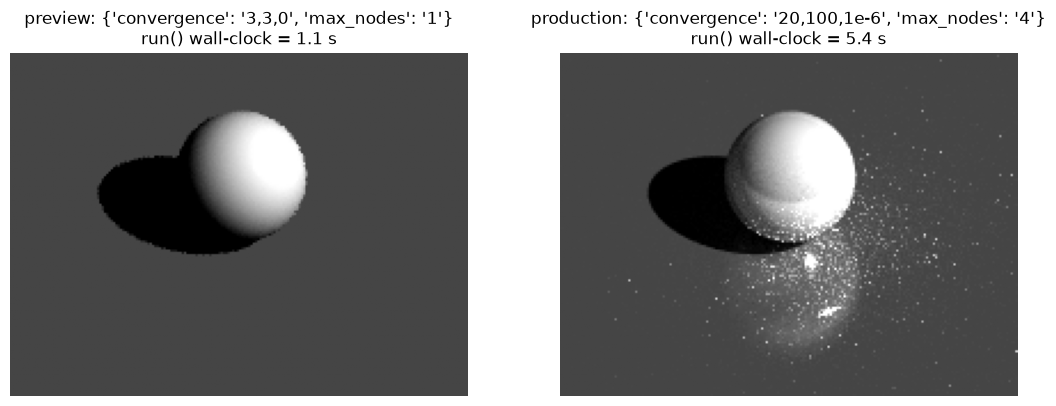

   preview: run()=  1.1s  image mean=4.6598e-03  ground-patch mean=4.1015e-03  ground-patch std/mean=0.000%
production: run()=  5.4s  image mean=5.1587e-03  ground-patch mean=4.1030e-03  ground-patch std/mean=0.200%
speed-up: 5.1x
production vs. Stage 8a default-settings seed-42 run, bitwise equal: True
cast shadow (1787 px): preview mean=3.53e-05  production mean=1.05e-03
preview is 9.7% darker overall; 35% of pixels differ by >1%


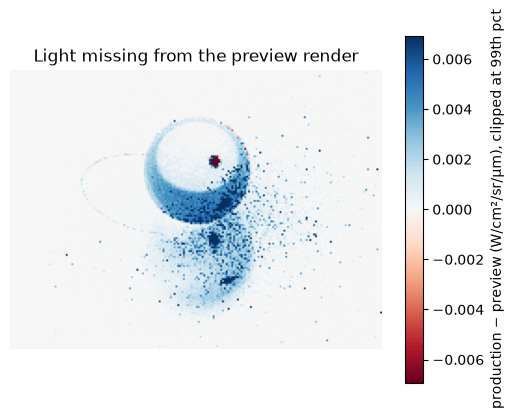

In [18]:
quality = {
    "preview":    dict(convergence="3,3,0",       max_nodes="1"),
    "production": dict(convergence="20,100,1e-6", max_nodes="4"),
}
qruns = {name: stage1_job(name, seed=42, **opts) for name, opts in quality.items()}

# Common display stretch so brightness differences between the two are real, not rescaled.
both = np.concatenate([qruns[n][0][:, :, 0].ravel() for n in qruns])
lo, hi = np.percentile(both, 2), np.percentile(both, 98)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for ax, (name, (cube, sec, sha)) in zip(axes, qruns.items()):
    ax.imshow(np.clip((cube[:, :, 0] - lo) / (hi - lo), 0, 1), cmap="gray")
    ax.set_title(f"{name}: {quality[name]}\nrun() wall-clock = {sec:.1f} s")
    ax.axis("off")
plt.show()

prev, prod = qruns["preview"][0][:, :, 0], qruns["production"][0][:, :, 0]
patch = (slice(0, 30), slice(0, 30))     # top-left corner: open, sunlit ground plane only
for name, img in [("preview", prev), ("production", prod)]:
    p = img[patch]
    print(f"{name:>10}: run()={qruns[name][1]:5.1f}s  image mean={img.mean():.4e}  "
          f"ground-patch mean={p.mean():.4e}  ground-patch std/mean={p.std() / p.mean():.3%}")
print(f"speed-up: {qruns['production'][1] / qruns['preview'][1]:.1f}x")
print(f"production vs. Stage 8a default-settings seed-42 run, bitwise equal: "
      f"{qruns['production'][2] == runs['seedA'][2]}")

# Where does preview lose light? Show the per-pixel shortfall relative to production.
shadow = prev < 0.3 * np.median(prev)  # pixels preview renders as (near-)black: the cast shadow
print(f"cast shadow ({shadow.sum()} px): preview mean={prev[shadow].mean():.2e}  "
      f"production mean={prod[shadow].mean():.2e}")
print(f"preview is {1 - prev.sum() / prod.sum():.1%} darker overall; "
      f"{(np.abs(prod - prev) > 0.01 * prod).mean():.0%} of pixels differ by >1%")

missing = prod - prev
lim = np.percentile(np.abs(missing), 99)          # same outlier-clipping as in 8a
plt.figure(figsize=(6, 4.5))
plt.imshow(missing, cmap="RdBu", vmin=-lim, vmax=lim)
plt.colorbar(label="production − preview (W/cm²/sr/µm), clipped at 99th pct")
plt.title("Light missing from the preview render")
plt.axis("off")
plt.show()

### Reading the quality comparison

What the numbers above show for this scene:

* **Preview is several times faster** (~5× here: 3 paths per pixel and 1 node vs. up to
  100 paths and 4 nodes per pixel).
* **Preview is not so much *noisy* as *biased*.** With `max_nodes=1` only the first hit and
  its direct sunlight are computed, so everything that needs a second bounce is simply
  missing:
  * the **lower half of the sphere**, which is lit by light reflected up from the ground, is
    the largest region of missing light in the difference map;
  * the **cast shadow is essentially black** in preview (about 30× darker than production),
    because skylight and light bounced off the sphere and ground — the only light
    reaching a shadowed surface — needs more than one node;
  * the **glossy reflection of the sphere in the ground plane**, and the scattered bright
    "firefly" pixels around it, are absent;
  * overall the image is ~10% darker, and about a third of the pixels differ by more than 1%.

  The open, sunlit ground (top-left patch) agrees to ~0.04% between the two, because it is
  lit almost entirely by the direct sun term. It is also perfectly uniform in preview
  (std/mean = 0): one direct term evaluated on a flat plane gives no pixel-to-pixel variation.
* **Production carries Monte-Carlo noise** — ~0.2% std/mean on the flat ground patch, plus the
  firefly pixels, which are rare high-radiance multi-bounce paths — because it actually
  samples the multi-bounce light transport, converging on the physically fuller answer.
* **The production run is bitwise identical to Stage 8a's seed-42 run with no flags**,
  confirming empirically that `20,100,1e-6` + 4 nodes *are* this build's defaults.

Use preview for geometry/pointing/timing sanity checks; never for radiometry. Fewer bounces
don't add noise; they leave out physics.

### What this establishes for provenance

To reproduce a DIRSIG5 run from this pipeline, the minimum run-control fields to record —
alongside the full generated input set (the `.jsim` and everything it references) and the
DIRSIG build version — are the **random seed** plus the **`convergence` (min, max,
threshold)** and **`max_nodes`** settings, recorded explicitly even when they are the defaults,
since an unseeded, flag-free run silently depends on this build's defaults (seed 0;
`20,100,1e-6`; 4 nodes). With those fields fixed, what we actually observed here — two
seed-42 runs into separate directories, and a single-threaded vs. all-cores run — is
**bitwise-identical** output (identical SHA-256 of `demo.img`), not merely statistically
similar output, while changing the seed changes the per-pixel noise. That standard has been
demonstrated on one machine with one DIRSIG build (2026.38.0); cross-machine, cross-version
and MPI reproducibility remain untested, so until they are checked, the claim for provenance
should be "bitwise on the same host and build," with statistical similarity as the fallback
expectation elsewhere.